In [1]:
import os
import tensorflow as tf
os.environ["TF_USE_CUDNN"] = "0"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
# -----------------------------
# Проверяем GPU
# -----------------------------
print("Devices:", tf.config.list_physical_devices())

Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import RNN, LSTMCell, Dense, LSTM, Conv1D, MaxPooling1D, Dropout, Input
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
data = pd.read_csv(
    './household_power_consumption.txt.gz',
    sep=';',
    na_values=['?', 'nan'],
    compression='gzip',
    low_memory=False
)

data['dt'] = pd.to_datetime(
    data['Date'] + ' ' + data['Time'],
    dayfirst=True,
    errors='coerce'
)

data = data.set_index('dt').drop(columns=['Date','Time'])

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [4]:
df = data.copy()

In [5]:
df.isna().sum()

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

# LSTM MODEL

In [168]:
def build_lstm_directml(df, feature_cols, target_col,
                        seq_len=24, epochs=10, batch_size=24):

    # ---------- 1. Масштабирование ----------
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    X_all = scaler_X.fit_transform(df[feature_cols])
    y_all = scaler_y.fit_transform(df[[target_col]])

    # ---------- 2. Создание последовательностей ----------
    X_seq, y_seq = [], []

    for i in range(seq_len, len(df)):
        X_seq.append(X_all[i-seq_len:i])
        y_seq.append(y_all[i])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)

    # ---------- 3. Train/test split ----------
    train_size = int(len(X_seq) * 0.8)

    X_train = X_seq[:train_size]
    y_train = y_seq[:train_size]

    X_test = X_seq[train_size:]
    y_test = y_seq[train_size:]

    n_features = X_train.shape[2]

    # ---------- 4. LSTM БЕЗ CuDNN ----------

    model = Sequential()
    
    model.add(Input(shape=(seq_len, n_features)))
    model.add(RNN(LSTMCell(100), return_sequences=True))
    model.add(Dropout(0.2))
    model.add(RNN(LSTMCell(70)))
    model.add(Dropout(0.3))
    model.add(Dense(1))
    
    model.compile(loss='mse', optimizer='adam')

    # -----------5. Тренировка
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True )
    
    history=model.fit(X_train,
                      y_train,
                      epochs=epochs,
                      batch_size=batch_size,
                      validation_data=(X_test, y_test),
                      callbacks=[early_stop],
                      verbose=1,
                      shuffle=False)


    # ---------- 6. Предсказание ----------
    y_pred_scaled = model.predict(X_test)
    y_pred_train_scaled = model.predict(X_train)

    # ---------- 7. Обратная трансформация ----------
    y_test_inv = scaler_y.inverse_transform(y_test)
    y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)

    y_train_inv = scaler_y.inverse_transform(y_train)
    y_pred_train_inv = scaler_y.inverse_transform(y_pred_train_scaled)
    
    # ---------- 8. Metrics (TRAIN) ----------
    mae_train = mean_absolute_error(y_train_inv, y_pred_train_inv)
    mse_train = mean_squared_error(y_train_inv, y_pred_train_inv)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train_inv, y_pred_train_inv)
    
    # ---------- 9. Metrics (TEST) ----------
    mae_test = mean_absolute_error(y_test_inv, y_pred_inv)
    mse_test = mean_squared_error(y_test_inv, y_pred_inv)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test_inv, y_pred_inv)

    
    return (model, history, y_test_inv, y_pred_inv, scaler_X, scaler_y, X_test, y_test,
                mae_train, mse_train, rmse_train, r2_train,
                mae_test, mse_test, rmse_test, r2_test
               )

In [169]:
def print_metrics():
    print("TRAIN:")
    print("MAE:", mae_train)
    print("MSE:", mse_train)
    print('RMSE', rmse_train)
    print("R2:", r2_train)
    
    print("\nTEST:")
    print("MAE:", mae_test)
    print("MSE:", mse_test)
    print('RMSE', rmse_test)
    print("R2:", r2_test)

def metrics_to_df(df_name=''):
    metrics_df = pd.DataFrame([
    {
        "model_name": df_name,
        "dataset": "train",
        "mae": mae_train,
        "mse": mse_train,
        "rmse": rmse_train,
        "r2": r2_train
    },
    {
        "model_name": df_name,
        "dataset": "test",
        "mae": mae_test,
        "mse": mse_test,
        "rmse": rmse_test,
        "r2": r2_test
    }
    ])
    metrics_df.to_csv(f'{df_name}.csv', index=False)

def permutation_importance(model, X_test, y_test, feature_names):
        baseline_pred = model.predict(X_test)
        baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
    
        importances = []
    
        for i, name in enumerate(feature_names):
            X_perm = X_test.copy()
            np.random.shuffle(X_perm[:, :, i])  # перемешиваем один признак
    
            perm_pred = model.predict(X_perm)
            perm_rmse = mean_squared_error(y_test, perm_pred) ** 0.5
    
            importances.append((name, perm_rmse - baseline_rmse))
    
        return sorted(importances, key=lambda x: x[1], reverse=True)

def show_importance():
    
    importances = permutation_importance(model, X_test, y_test, feature_cols)
    
    for name, score in importances:
        print(f"{name:20s}  ΔRMSE = {score:.5f}")
    
    # Разворачиваем в два списка
    features = [f[0] for f in importances]
    scores = [f[1] for f in importances]
    
    plt.figure(figsize=(12, 6))
    plt.barh(features, scores, color='skyblue')
    plt.title("Permutation Importance", fontsize=14)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.gca().invert_yaxis()  # чтобы важные признаки были сверху
    plt.tight_layout()
    plt.show()

# Feature engineering

### Resampling

In [7]:
data_resampled_H = df.resample('h').agg({
    'Global_active_power': 'mean',
    'Global_reactive_power': 'mean',
    'Voltage': 'mean',
    'Global_intensity': 'mean',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum'
})

In [8]:
data_resampled_H.shape

(34589, 7)

In [9]:
mask_empty_hours = data_resampled_H['Global_active_power'].isna()
cols_sum = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

data_resampled_H.loc[mask_empty_hours, cols_sum] = \
    data_resampled_H.loc[mask_empty_hours, cols_sum].replace(0, np.nan)

In [10]:
data_resampled_H.isna().sum()

Global_active_power      421
Global_reactive_power    421
Voltage                  421
Global_intensity         421
Sub_metering_1           421
Sub_metering_2           421
Sub_metering_3           421
dtype: int64

# Step 1
### Missing value imputation. 
### MSTL method

In [11]:
from statsmodels.tsa.seasonal import MSTL

results = {}
seasonal_components = pd.DataFrame(index=data_resampled_H.index)
deseasonalised = pd.DataFrame(index=data_resampled_H.index)

for col in data_resampled_H.columns:

    # 1. Импутация для MSTL (как в baseline)
    s_clean = (
        data_resampled_H[col]
        .interpolate(method="linear")  # baseline interpolation
        .ffill()
        .bfill()
    )

    # 2. MSTL
    m = MSTL(s_clean, periods=[24, 24*7])
    res = m.fit()
    results[col] = res

    # 3. Сезонность
    seasonal = res.seasonal.sum(axis=1)
    seasonal_components[col] = seasonal

    # 4. Де-сезонализация (только сезонность!)
    deseasonalised[col] = s_clean - seasonal

# 5. Импутация де-сезонализированного ряда (как baseline)
deseasonalised_imputed = deseasonalised.interpolate(method="linear").ffill().bfill()

In [110]:
data_imputed_MSTL = deseasonalised_imputed + seasonal_components

### MSTL_imputed training

In [66]:
target_col = 'Global_active_power'
feature_cols = data_imputed_MSTL.columns.drop(target_col).tolist()
feature_cols

['Global_reactive_power',
 'Voltage',
 'Global_intensity',
 'Sub_metering_1',
 'Sub_metering_2',
 'Sub_metering_3']

In [67]:
model, history, y_test_inv, y_pred_inv, scaler_X, scaler_y, X_test, y_test, mae_train, mse_train, rmse_train, r2_train, mae_test, mse_test, rmse_test, r2_test = build_lstm_directml(
    data_imputed_MSTL,
    feature_cols,
    target_col,
    seq_len=24,
    epochs=20,
    batch_size=1024  
)

Epoch 1/20
28/28 [==============================] - 5s 123ms/step - loss: 0.0222 - val_loss: 0.0112
Epoch 2/20
28/28 [==============================] - 3s 113ms/step - loss: 0.0193 - val_loss: 0.0114
Epoch 3/20
28/28 [==============================] - 3s 113ms/step - loss: 0.0176 - val_loss: 0.0107
Epoch 4/20
28/28 [==============================] - 3s 116ms/step - loss: 0.0165 - val_loss: 0.0099
Epoch 5/20
28/28 [==============================] - 3s 115ms/step - loss: 0.0150 - val_loss: 0.0089
Epoch 6/20
28/28 [==============================] - 3s 112ms/step - loss: 0.0138 - val_loss: 0.0082
Epoch 7/20
28/28 [==============================] - 3s 113ms/step - loss: 0.0129 - val_loss: 0.0079
Epoch 8/20
28/28 [==============================] - 3s 114ms/step - loss: 0.0122 - val_loss: 0.0077
Epoch 9/20
28/28 [==============================] - 3s 113ms/step - loss: 0.0118 - val_loss: 0.0075
Epoch 10/20
28/28 [==============================] - 3s 116ms/step - loss: 0.0116 - val_loss: 0.0074

In [68]:
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)
print("TRAIN:")
print("MAE:", mae_train)
print("MSE:", mse_train)
print('RMSE', rmse_train)
print("R2:", r2_train)

print("\nTEST:")
print("MAE:", mae_test)
print("MSE:", mse_test)
print('RMSE', rmse_test)
print("R2:", r2_test)

TRAIN:
MAE: 0.4265403610782975
MSE: 0.36435298788861814
RMSE 0.6036165901369992
R2: 0.5795608607158484

TEST:
MAE: 0.376324254821773
MSE: 0.26585190675084225
RMSE 0.5156082880936286
R2: 0.49753007073529665


In [69]:
metrics_df = pd.DataFrame([
    {
        "model_name": "LSTM_MSTL_imputed",
        "dataset": "train",
        "mae": mae_train,
        "mse": mse_train,
        "rmse": rmse_train,
        "r2": r2_train
    },
    {
        "model_name": "LSTM_MSTL_imputed",
        "dataset": "test",
        "mae": mae_test,
        "mse": mse_test,
        "rmse": rmse_test,
        "r2": r2_test
    }
])

In [70]:
metrics_df.to_csv("model_MSTL_metrics.csv", index=False)

In [71]:
MSTL_metrics = pd.read_csv("model_MSTL_metrics.csv")
MSTL_metrics

,model_name,dataset,mae,mse,rmse,r2
0,LSTM_MSTL_imputed,train,0.426540,0.364353,0.603617,0.579561
1,LSTM_MSTL_imputed,test,0.376324,0.265852,0.515608,0.497530


# Step 2. New Features
### 2.1 Calendar Features

#### Remove `Global_reactive_power`

In [111]:
data_imputed_MSTL.drop('Global_reactive_power', axis=1, inplace=True)

,Global_active_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,
2006-12-16 17:00:00,4.222889,234.643889,18.100000,0.0,19.0,607.0
2006-12-16 18:00:00,3.632200,234.580167,15.600000,0.0,403.0,1012.0
2006-12-16 19:00:00,3.400233,233.232500,14.503333,0.0,86.0,1001.0
2006-12-16 20:00:00,3.268567,234.071500,13.916667,0.0,0.0,1007.0
2006-12-16 21:00:00,3.056467,237.158667,13.046667,0.0,25.0,1033.0
...,...,...,...,...,...,...
2010-11-26 17:00:00,1.725900,237.069667,7.216667,0.0,0.0,772.0
2010-11-26 18:00:00,1.573467,237.531833,6.620000,0.0,0.0,0.0
2010-11-26 19:00:00,1.659333,236.741000,7.056667,0.0,4.0,0.0


In [112]:
# Календарные признаки
data_calendar = data_imputed_MSTL.copy()
data_calendar["hour"] = data_calendar.index.hour
data_calendar["is_weekend"] = (data_calendar.index.dayofweek >= 5).astype(int)
data_calendar.shape

(34589, 8)

In [113]:
feature_cols = data_calendar.columns.drop(target_col).tolist()
feature_cols

['Voltage',
 'Global_intensity',
 'Sub_metering_1',
 'Sub_metering_2',
 'Sub_metering_3',
 'hour',
 'is_weekend']

### MSTL + new feature training

In [114]:
model, history, y_test_inv, y_pred_inv, scaler_X, scaler_y, X_test, y_test, mae_train, mse_train, rmse_train, r2_train, mae_test, mse_test, rmse_test, r2_test = build_lstm_directml(
    data_calendar,
    feature_cols,
    target_col,
    seq_len=24,
    epochs=30,
    batch_size=1024  
)

Epoch 1/30
28/28 [==============================] - 5s 121ms/step - loss: 0.0292 - val_loss: 0.0111
Epoch 2/30
28/28 [==============================] - 3s 113ms/step - loss: 0.0186 - val_loss: 0.0111
Epoch 3/30
28/28 [==============================] - 3s 112ms/step - loss: 0.0179 - val_loss: 0.0106
Epoch 4/30
28/28 [==============================] - 3s 112ms/step - loss: 0.0175 - val_loss: 0.0103
Epoch 5/30
28/28 [==============================] - 3s 112ms/step - loss: 0.0169 - val_loss: 0.0101
Epoch 6/30
28/28 [==============================] - 3s 113ms/step - loss: 0.0164 - val_loss: 0.0098
Epoch 7/30
28/28 [==============================] - 3s 113ms/step - loss: 0.0159 - val_loss: 0.0094
Epoch 8/30
28/28 [==============================] - 3s 112ms/step - loss: 0.0151 - val_loss: 0.0090
Epoch 9/30
28/28 [==============================] - 3s 112ms/step - loss: 0.0143 - val_loss: 0.0086
Epoch 10/30
28/28 [==============================] - 3s 115ms/step - loss: 0.0135 - val_loss: 0.0082

In [115]:
def print_metrics():
    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)
    print("TRAIN:")
    print("MAE:", mae_train)
    print("MSE:", mse_train)
    print('RMSE', rmse_train)
    print("R2:", r2_train)
    
    print("\nTEST:")
    print("MAE:", mae_test)
    print("MSE:", mse_test)
    print('RMSE', rmse_test)
    print("R2:", r2_test)

TRAIN:
MAE: 0.421455422427484
MSE: 0.35435764768971084
RMSE 0.5952794702404164
R2: 0.591094819184073

TEST:
MAE: 0.373404301190212
MSE: 0.25798642822651363
RMSE 0.5079236440908353
R2: 0.5123961158430959


In [116]:
metrics_df = pd.DataFrame([
    {
        "model_name": "MSTL_calendar",
        "dataset": "train",
        "mae": mae_train,
        "mse": mse_train,
        "rmse": rmse_train,
        "r2": r2_train
    },
    {
        "model_name": "MSTL_calendar",
        "dataset": "test",
        "mae": mae_test,
        "mse": mse_test,
        "rmse": rmse_test,
        "r2": r2_test
    }
])
metrics_df.to_csv("MSTL+calendar.csv", index=False)

### 2.2 Cycle features

In [127]:
# Циклические признаки
data_calendar_cycle = data_calendar.copy()
data_calendar_cycle["hour_sin"] = np.sin(2 * np.pi * data_calendar_cycle.index.hour / 24)
data_calendar_cycle["hour_cos"] = np.cos(2 * np.pi * data_calendar_cycle.index.hour / 24)

data_calendar_cycle.shape

(34589, 10)

In [128]:
feature_cols = data_calendar_cycle.columns.drop(target_col).tolist()
feature_cols

['Voltage',
 'Global_intensity',
 'Sub_metering_1',
 'Sub_metering_2',
 'Sub_metering_3',
 'hour',
 'is_weekend',
 'hour_sin',
 'hour_cos']

In [129]:
model, history, y_test_inv, y_pred_inv, scaler_X, scaler_y, X_test, y_test, mae_train, mse_train, rmse_train, r2_train, mae_test, mse_test, rmse_test, r2_test = build_lstm_directml(
    data_calendar_cycle,
    feature_cols,
    target_col,
    seq_len=24,
    epochs=30,
    batch_size=1024  
)

Epoch 1/30
28/28 [==============================] - 5s 122ms/step - loss: 0.0279 - val_loss: 0.0113
Epoch 2/30
28/28 [==============================] - 3s 112ms/step - loss: 0.0191 - val_loss: 0.0109
Epoch 3/30
28/28 [==============================] - 3s 112ms/step - loss: 0.0179 - val_loss: 0.0104
Epoch 4/30
28/28 [==============================] - 3s 114ms/step - loss: 0.0168 - val_loss: 0.0098
Epoch 5/30
28/28 [==============================] - 3s 113ms/step - loss: 0.0162 - val_loss: 0.0093
Epoch 6/30
28/28 [==============================] - 3s 112ms/step - loss: 0.0156 - val_loss: 0.0088
Epoch 7/30
28/28 [==============================] - 3s 113ms/step - loss: 0.0144 - val_loss: 0.0085
Epoch 8/30
28/28 [==============================] - 3s 112ms/step - loss: 0.0134 - val_loss: 0.0083
Epoch 9/30
28/28 [==============================] - 3s 112ms/step - loss: 0.0129 - val_loss: 0.0081
Epoch 10/30
28/28 [==============================] - 3s 113ms/step - loss: 0.0124 - val_loss: 0.0078

In [130]:
print_metrics()

TRAIN:
MAE: 0.41296723746358527
MSE: 0.34670053363192344
RMSE 0.5888128171430403
R2: 0.5999306200444213

TEST:
MAE: 0.36700014962458316
MSE: 0.2514250104432255
RMSE 0.5014229855553348
R2: 0.5247974379541118


In [136]:
metrics_to_df('MSTL_calendar_cycle')

### 2.3 Lag features

In [140]:
def add_lags(df):
    # Global_intensity — главный признак
    for lag in [1, 2, 3, 6, 12, 24, 48]:
        df[f"Global_intensity_lag_{lag}"] = df["Global_intensity"].shift(lag)

    # Sub_metering_3 — пики нагрузки
    for lag in [1, 6, 24, 48]:
        df[f"Sub_metering_3_lag_{lag}"] = df["Sub_metering_3"].shift(lag)
        
    return df

data_calendar_cycle_lags = data_calendar_cycle.copy()
data_calendar_cycle_lags = add_lags(data_calendar_cycle_lags).copy()
data_calendar_cycle_lags = data_calendar_cycle_lags.dropna()

In [141]:
data_calendar_cycle_lags.shape

(34541, 21)

In [150]:
feature_cols = data_calendar_cycle_lags.columns.drop(target_col).tolist()
feature_cols

['Voltage',
 'Global_intensity',
 'Sub_metering_1',
 'Sub_metering_2',
 'Sub_metering_3',
 'hour',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'Global_intensity_lag_1',
 'Global_intensity_lag_2',
 'Global_intensity_lag_3',
 'Global_intensity_lag_6',
 'Global_intensity_lag_12',
 'Global_intensity_lag_24',
 'Global_intensity_lag_48',
 'Sub_metering_3_lag_1',
 'Sub_metering_3_lag_6',
 'Sub_metering_3_lag_24',
 'Sub_metering_3_lag_48']

In [151]:
model, history, y_test_inv, y_pred_inv, scaler_X, scaler_y, X_test, y_test, mae_train, mse_train, rmse_train, r2_train, mae_test, mse_test, rmse_test, r2_test = build_lstm_directml(
    data_calendar_cycle_lags,
    feature_cols,
    target_col,
    seq_len=24,
    epochs=30,
    batch_size=1024  
)

Epoch 1/30
27/27 [==============================] - 5s 123ms/step - loss: 0.0269 - val_loss: 0.0113
Epoch 2/30
27/27 [==============================] - 3s 114ms/step - loss: 0.0192 - val_loss: 0.0107
Epoch 3/30
27/27 [==============================] - 3s 113ms/step - loss: 0.0169 - val_loss: 0.0097
Epoch 4/30
27/27 [==============================] - 3s 115ms/step - loss: 0.0156 - val_loss: 0.0091
Epoch 5/30
27/27 [==============================] - 3s 113ms/step - loss: 0.0148 - val_loss: 0.0087
Epoch 6/30
27/27 [==============================] - 3s 113ms/step - loss: 0.0140 - val_loss: 0.0082
Epoch 7/30
27/27 [==============================] - 3s 114ms/step - loss: 0.0130 - val_loss: 0.0079
Epoch 8/30
27/27 [==============================] - 3s 113ms/step - loss: 0.0125 - val_loss: 0.0078
Epoch 9/30
27/27 [==============================] - 3s 114ms/step - loss: 0.0122 - val_loss: 0.0076
Epoch 10/30
27/27 [==============================] - 3s 114ms/step - loss: 0.0119 - val_loss: 0.0074

In [164]:
print_metrics()

TRAIN:
MAE: 0.4091451771000971
MSE: 0.34893522828573204
RMSE 0.5907073965050141
R2: 0.5969840802465254

TEST:
MAE: 0.3610606174467477
MSE: 0.24985467157347685
RMSE 0.4998546504469843
R2: 0.5279709678337028


In [165]:
metrics_to_df('MSTL_calendar_cycle_lags')

216/216 [==============================] - 3s 13ms/step
Global_intensity      ΔRMSE = 0.03310
hour                  ΔRMSE = 0.00737
Sub_metering_3_lag_1  ΔRMSE = 0.00604
hour_sin              ΔRMSE = 0.00452
hour_cos              ΔRMSE = 0.00379
Sub_metering_3        ΔRMSE = 0.00214
Global_intensity_lag_1  ΔRMSE = 0.00131
Voltage               ΔRMSE = 0.00126
Global_intensity_lag_3  ΔRMSE = 0.00116
Global_intensity_lag_6  ΔRMSE = 0.00100
is_weekend            ΔRMSE = 0.00100
Global_intensity_lag_12  ΔRMSE = 0.00082
Sub_metering_3_lag_6  ΔRMSE = 0.00080
Global_intensity_lag_2  ΔRMSE = 0.00073
Global_intensity_lag_24  ΔRMSE = 0.00055
Sub_metering_3_lag_48  ΔRMSE = 0.00040
Global_intensity_lag_48  ΔRMSE = 0.00035
Sub_metering_3_lag_24  ΔRMSE = 0.00017
Sub_metering_2        ΔRMSE = 0.00017
Sub_metering_1        ΔRMSE = 0.00010


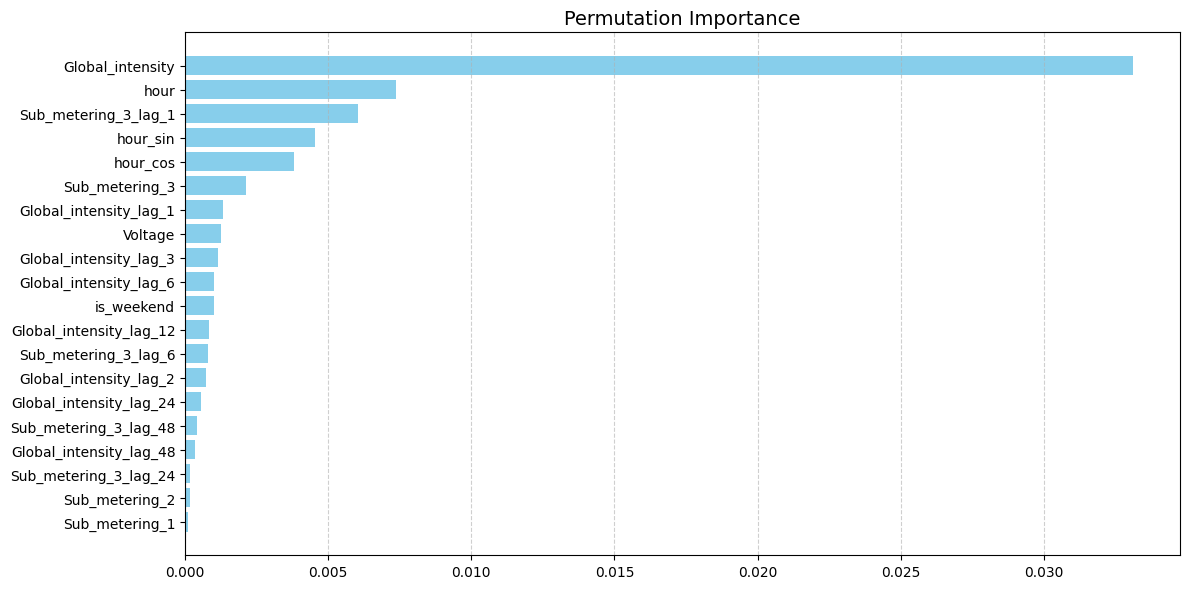

In [155]:
show_importance()

### 2.4 Rolling features

In [172]:
def add_rolling(df):
    df = df.copy()

    # Global_active_power — главный признак
    for w in [6, 24, 48]:
        df[f"Global_active_power_roll_mean_{w}"] = (
            df["Global_active_power"].shift(1).rolling(window=w, min_periods=1).mean()
        )
        df[f"Global_active_power_roll_std_{w}"] = (
            df["Global_active_power"].shift(1).rolling(window=w, min_periods=1).std()
        )

    # Global_intensity — главный признак
    for w in [6, 24, 48]:
        df[f"Global_intensity_roll_mean_{w}"] = (
            df["Global_intensity"].shift(1).rolling(window=w, min_periods=1).mean()
        )
        df[f"Global_intensity_roll_std_{w}"] = (
            df["Global_intensity"].shift(1).rolling(window=w, min_periods=1).std()
        )

    # Sub_metering_3 — пики нагрузки
    for w in [6, 24, 48]:
        df[f"Sub_metering_3_roll_mean_{w}"] = (
            df["Sub_metering_3"].shift(1).rolling(window=w, min_periods=1).mean()
        )
        df[f"Sub_metering_3_roll_std_{w}"] = (
            df["Sub_metering_3"].shift(1).rolling(window=w, min_periods=1).std()
        )

    return df

data_calendar_cycle_lags_roll = data_calendar_cycle_lags.copy()
data_calendar_cycle_lags_roll = add_rolling(data_calendar_cycle_lags_roll).copy()
data_calendar_cycle_lags_roll = data_calendar_cycle_lags_roll.dropna()

In [173]:
data_calendar_cycle_lags_roll.shape

(34539, 39)

In [188]:
feature_cols = data_calendar_cycle_lags_roll.columns.drop(target_col).tolist()
feature_cols = ['Voltage',
 'Global_intensity',
 'Sub_metering_1',
 'Sub_metering_2',
 'Sub_metering_3',
 'hour',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'Global_intensity_lag_1',
 'Global_intensity_lag_2',
 'Global_intensity_lag_3',
 'Global_intensity_lag_6',
 'Global_intensity_lag_12',
 'Global_intensity_lag_24',
 'Global_intensity_lag_48',
 'Sub_metering_3_lag_1',
 'Sub_metering_3_lag_6',
 'Sub_metering_3_lag_24',
 'Sub_metering_3_lag_48',
 'Global_active_power_roll_mean_6',
 #'Global_active_power_roll_std_6',
 'Global_active_power_roll_mean_24',
 #'Global_active_power_roll_std_24',
 'Global_active_power_roll_mean_48',
 #'Global_active_power_roll_std_48',
 #'Global_intensity_roll_mean_6',
 'Global_intensity_roll_std_6',
 'Global_intensity_roll_mean_24',
 'Global_intensity_roll_std_24',
 'Global_intensity_roll_mean_48',
 #'Global_intensity_roll_std_48',
 'Sub_metering_3_roll_mean_6',
 #'Sub_metering_3_roll_std_6',
 #'Sub_metering_3_roll_mean_24',
 'Sub_metering_3_roll_std_24',
 'Sub_metering_3_roll_mean_48',
 #'Sub_metering_3_roll_std_48'
]
feature_cols

['Voltage',
 'Global_intensity',
 'Sub_metering_1',
 'Sub_metering_2',
 'Sub_metering_3',
 'hour',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'Global_intensity_lag_1',
 'Global_intensity_lag_2',
 'Global_intensity_lag_3',
 'Global_intensity_lag_6',
 'Global_intensity_lag_12',
 'Global_intensity_lag_24',
 'Global_intensity_lag_48',
 'Sub_metering_3_lag_1',
 'Sub_metering_3_lag_6',
 'Sub_metering_3_lag_24',
 'Sub_metering_3_lag_48',
 'Global_active_power_roll_mean_6',
 'Global_active_power_roll_mean_24',
 'Global_active_power_roll_mean_48',
 'Global_intensity_roll_std_6',
 'Global_intensity_roll_mean_24',
 'Global_intensity_roll_std_24',
 'Global_intensity_roll_mean_48',
 'Sub_metering_3_roll_mean_6',
 'Sub_metering_3_roll_std_24',
 'Sub_metering_3_roll_mean_48']

In [189]:
model, history, y_test_inv, y_pred_inv, scaler_X, scaler_y, X_test, y_test, mae_train, mse_train, rmse_train, r2_train, mae_test, mse_test, rmse_test, r2_test = build_lstm_directml(
    data_calendar_cycle_lags_roll,
    feature_cols,
    target_col,
    seq_len=24,
    epochs=40,
    batch_size=1024  
)

Epoch 1/40
27/27 [==============================] - 5s 126ms/step - loss: 0.0374 - val_loss: 0.0118
Epoch 2/40
27/27 [==============================] - 3s 120ms/step - loss: 0.0190 - val_loss: 0.0105
Epoch 3/40
27/27 [==============================] - 3s 115ms/step - loss: 0.0176 - val_loss: 0.0100
Epoch 4/40
27/27 [==============================] - 3s 115ms/step - loss: 0.0162 - val_loss: 0.0095
Epoch 5/40
27/27 [==============================] - 3s 116ms/step - loss: 0.0155 - val_loss: 0.0090
Epoch 6/40
27/27 [==============================] - 3s 114ms/step - loss: 0.0148 - val_loss: 0.0087
Epoch 7/40
27/27 [==============================] - 3s 117ms/step - loss: 0.0145 - val_loss: 0.0084
Epoch 8/40
27/27 [==============================] - 3s 114ms/step - loss: 0.0141 - val_loss: 0.0084
Epoch 9/40
27/27 [==============================] - 3s 113ms/step - loss: 0.0136 - val_loss: 0.0081
Epoch 10/40
27/27 [==============================] - 3s 115ms/step - loss: 0.0129 - val_loss: 0.0078

In [190]:
print_metrics()

TRAIN:
MAE: 0.4052034103674861
MSE: 0.34073871198261624
RMSE 0.5837282860908971
R2: 0.6064325968961373

TEST:
MAE: 0.3586105720851096
MSE: 0.24774510484072895
RMSE 0.4977399972282004
R2: 0.5319831422084711


In [191]:
metrics_to_df('MSTL_calendar_cycle_lags_roll')

216/216 [==============================] - 3s 13ms/step
Global_intensity      ΔRMSE = 0.03896
Sub_metering_3_lag_1  ΔRMSE = 0.01178
hour                  ΔRMSE = 0.01008
hour_sin              ΔRMSE = 0.00929
hour_cos              ΔRMSE = 0.00476
Sub_metering_3        ΔRMSE = 0.00293
Global_active_power_roll_mean_6  ΔRMSE = 0.00238
Voltage               ΔRMSE = 0.00147
Global_active_power_roll_mean_48  ΔRMSE = 0.00143
Sub_metering_3_lag_6  ΔRMSE = 0.00119
Sub_metering_3_roll_mean_6  ΔRMSE = 0.00107
Global_intensity_lag_1  ΔRMSE = 0.00101
is_weekend            ΔRMSE = 0.00098
Global_intensity_lag_24  ΔRMSE = 0.00091
Global_intensity_lag_6  ΔRMSE = 0.00091
Global_intensity_lag_12  ΔRMSE = 0.00078
Sub_metering_3_roll_mean_48  ΔRMSE = 0.00057
Global_intensity_lag_2  ΔRMSE = 0.00054
Global_active_power_roll_mean_24  ΔRMSE = 0.00050
Global_intensity_roll_mean_24  ΔRMSE = 0.00040
Sub_metering_3_lag_24  ΔRMSE = 0.00037
Global_intensity_roll_std_6  ΔRMSE = 0.00037
Sub_metering_2        ΔRMSE = 0

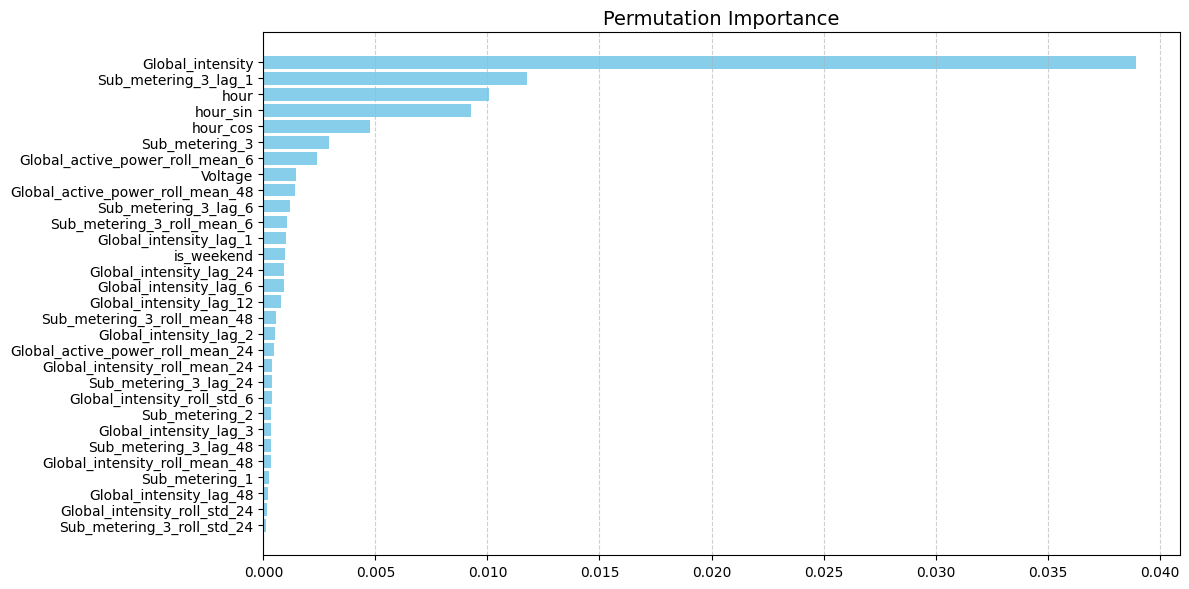

In [192]:
show_importance()

# Step 3 Best Feature Selection

In [193]:
final_data = data_calendar_cycle_lags_roll.copy()

In [254]:
feature_cols = [
    # календарные
    
    'hour',
    'hour_sin', 
    'hour_cos',
    #'dayofweek', 
    #'dow_sin', 
    'is_weekend',

    # исходные
    
    'Global_intensity', 
    'Sub_metering_3',
    'Sub_metering_2',
    'Sub_metering_1',
    'Voltage',

    # лаги Global_intensity
    
    'Global_intensity_lag_1', 
    #'Global_intensity_lag_2',
    #'Global_intensity_lag_3', 
    'Global_intensity_lag_6',
    #'Global_intensity_lag_12', 
    #'Global_intensity_lag_24',
    #'Global_intensity_lag_48',

    # лаги Sub_metering_3
    
    'Sub_metering_3_lag_1', 
    #'Sub_metering_3_lag_6',
    #'Sub_metering_3_lag_24', 
    #'Sub_metering_3_lag_48',

    # rolling Global_intensity
    
    #'Global_intensity_roll_mean_6', 
    #'Global_intensity_roll_std_6',
    'Global_intensity_roll_mean_24', 
    'Global_intensity_roll_std_24',

    # rolling Sub_metering_3
    
    #'Sub_metering_3_roll_mean_6', 
    #'Sub_metering_3_roll_std_6',
    #'Sub_metering_3_roll_mean_24', 
    'Sub_metering_3_roll_std_24',

    # rolling target
    
    'Global_active_power_roll_mean_6', 
    #'Global_active_power_roll_std_6',
    'Global_active_power_roll_mean_24', 
    'Global_active_power_roll_std_24'
]

In [219]:
%%time
model, history, y_test_inv, y_pred_inv, scaler_X, scaler_y, X_test, y_test, mae_train, mse_train, rmse_train, r2_train, mae_test, mse_test, rmse_test, r2_test = build_lstm_directml(
    final_data,
    feature_cols,
    target_col,
    seq_len=24,
    epochs=50,
    batch_size=512   
)

Epoch 1/50
54/54 [==============================] - 8s 119ms/step - loss: 0.0246 - val_loss: 0.0121
Epoch 2/50
54/54 [==============================] - 6s 113ms/step - loss: 0.0200 - val_loss: 0.0099
Epoch 3/50
54/54 [==============================] - 6s 114ms/step - loss: 0.0155 - val_loss: 0.0088
Epoch 4/50
54/54 [==============================] - 6s 114ms/step - loss: 0.0137 - val_loss: 0.0079
Epoch 5/50
54/54 [==============================] - 6s 114ms/step - loss: 0.0125 - val_loss: 0.0075
Epoch 6/50
54/54 [==============================] - 6s 114ms/step - loss: 0.0118 - val_loss: 0.0071
Epoch 7/50
54/54 [==============================] - 6s 114ms/step - loss: 0.0112 - val_loss: 0.0068
Epoch 8/50
54/54 [==============================] - 6s 114ms/step - loss: 0.0109 - val_loss: 0.0067
Epoch 9/50
54/54 [==============================] - 6s 114ms/step - loss: 0.0105 - val_loss: 0.0065
Epoch 10/50
54/54 [==============================] - 6s 114ms/step - loss: 0.0102 - val_loss: 0.0065

KeyboardInterrupt: 

In [212]:
print_metrics()

TRAIN:
MAE: 0.3765283314230051
MSE: 0.2956026128168171
RMSE 0.5436934916079252
R2: 0.6585666712182479

TEST:
MAE: 0.33475156527876176
MSE: 0.2205945755035986
RMSE 0.4696749679337814
R2: 0.5832733803583208


In [214]:
metrics_to_df('MSTL_best_features')

216/216 [==============================] - 3s 13ms/step
Global_intensity      ΔRMSE = 0.06921
hour_sin              ΔRMSE = 0.00940
Sub_metering_3_lag_1  ΔRMSE = 0.00918
hour                  ΔRMSE = 0.00845
hour_cos              ΔRMSE = 0.00801
Sub_metering_3        ΔRMSE = 0.00557
Sub_metering_2        ΔRMSE = 0.00263
Global_intensity_lag_6  ΔRMSE = 0.00235
Sub_metering_1        ΔRMSE = 0.00215
Global_active_power_roll_mean_6  ΔRMSE = 0.00191
is_weekend            ΔRMSE = 0.00173
Sub_metering_3_roll_std_24  ΔRMSE = 0.00109
Global_intensity_lag_1  ΔRMSE = 0.00101
Voltage               ΔRMSE = 0.00071
Global_active_power_roll_mean_24  ΔRMSE = 0.00053
Global_intensity_roll_mean_24  ΔRMSE = 0.00043


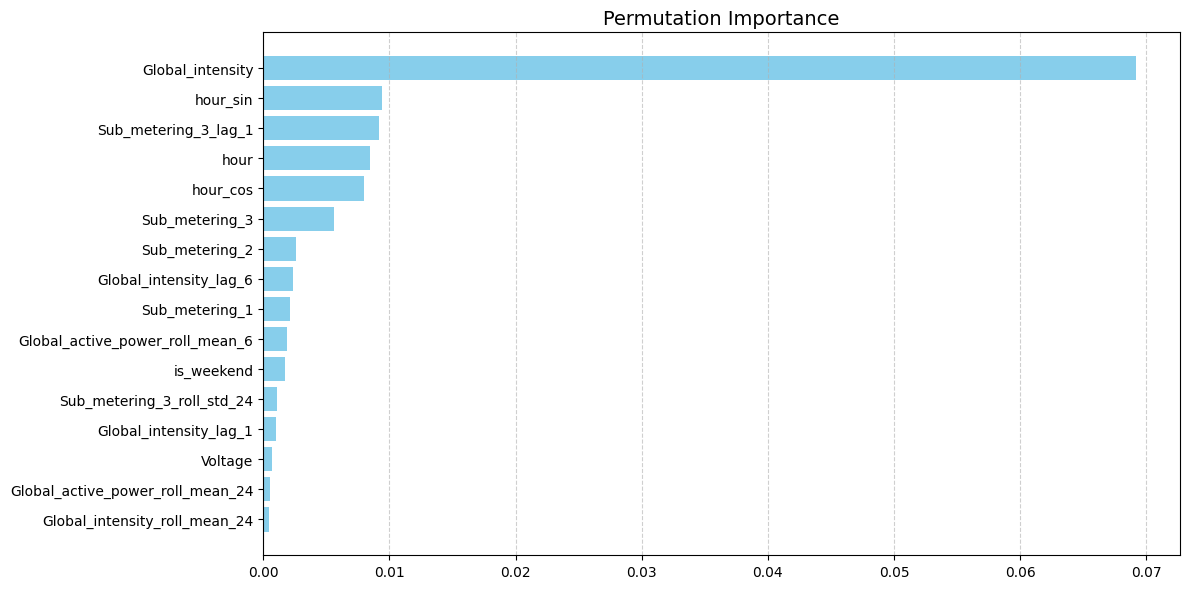

In [213]:
show_importance()

# Step 4 Model best params

In [272]:
def build_best_lstm_directml(df, feature_cols, target_col,
                        seq_len=24, epochs=10, batch_size=24):

    # ---------- 1. Масштабирование ----------
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    X_all = scaler_X.fit_transform(df[feature_cols])
    y_all = scaler_y.fit_transform(df[[target_col]])

    # ---------- 2. Создание последовательностей ----------
    X_seq, y_seq = [], []

    for i in range(seq_len, len(df)):
        X_seq.append(X_all[i-seq_len:i])
        y_seq.append(y_all[i])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)

    # ---------- 3. Train/test split ----------
    train_size = int(len(X_seq) * 0.8)

    X_train = X_seq[:train_size]
    y_train = y_seq[:train_size]

    X_test = X_seq[train_size:]
    y_test = y_seq[train_size:]

    n_features = X_train.shape[2]

    # ---------- 4. LSTM БЕЗ CuDNN ----------
    from tensorflow.keras.regularizers import l2

    model = Sequential()
    
    model.add(Input(shape=(seq_len, n_features)))
    model.add(RNN(LSTMCell(128, kernel_regularizer=l2(1e-4)),return_sequences=True))
    model.add(Dropout(0.2))
    
    model.add(RNN(LSTMCell(64, kernel_regularizer=l2(1e-4))))
    model.add(Dropout(0.2))
    
    model.add(Dense(16, kernel_regularizer=l2(1e-4), activation='relu'))
    model.add(Dense(1))
    
    model.compile(loss='mse', optimizer='adam')

    # -----------5. Тренировка
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True )
    
    history=model.fit(X_train,
                      y_train,
                      epochs=epochs,
                      batch_size=batch_size,
                      validation_data=(X_test, y_test),
                      callbacks=[early_stop],
                      verbose=1,
                      shuffle=False)


    # ---------- 6. Предсказание ----------
    y_pred_scaled = model.predict(X_test)
    y_pred_train_scaled = model.predict(X_train)

    # ---------- 7. Обратная трансформация ----------
    y_test_inv = scaler_y.inverse_transform(y_test)
    y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)

    y_train_inv = scaler_y.inverse_transform(y_train)
    y_pred_train_inv = scaler_y.inverse_transform(y_pred_train_scaled)
    
    # ---------- 8. Metrics (TRAIN) ----------
    mae_train = mean_absolute_error(y_train_inv, y_pred_train_inv)
    mse_train = mean_squared_error(y_train_inv, y_pred_train_inv)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train_inv, y_pred_train_inv)
    
    # ---------- 9. Metrics (TEST) ----------
    mae_test = mean_absolute_error(y_test_inv, y_pred_inv)
    mse_test = mean_squared_error(y_test_inv, y_pred_inv)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test_inv, y_pred_inv)

    
    return (model, history, y_test_inv, y_pred_inv, scaler_X, scaler_y, X_test, y_test,
                mae_train, mse_train, rmse_train, r2_train,
                mae_test, mse_test, rmse_test, r2_test
               )

In [273]:
%%time
model, history, y_test_inv, y_pred_inv, scaler_X, scaler_y, X_test, y_test, mae_train, mse_train, rmse_train, r2_train, mae_test, mse_test, rmse_test, r2_test = build_best_lstm_directml(
    final_data,
    feature_cols,
    target_col,
    seq_len=24,
    epochs=50,
    batch_size=512   
)

Epoch 1/50
54/54 [==============================] - 9s 129ms/step - loss: 0.0416 - val_loss: 0.0271
Epoch 2/50
54/54 [==============================] - 7s 126ms/step - loss: 0.0317 - val_loss: 0.0211
Epoch 3/50
54/54 [==============================] - 6s 119ms/step - loss: 0.0257 - val_loss: 0.0179
Epoch 4/50
54/54 [==============================] - 6s 119ms/step - loss: 0.0221 - val_loss: 0.0156
Epoch 5/50
54/54 [==============================] - 6s 118ms/step - loss: 0.0201 - val_loss: 0.0140
Epoch 6/50
54/54 [==============================] - 6s 119ms/step - loss: 0.0183 - val_loss: 0.0134
Epoch 7/50
54/54 [==============================] - 6s 116ms/step - loss: 0.0171 - val_loss: 0.0125
Epoch 8/50
54/54 [==============================] - 6s 114ms/step - loss: 0.0162 - val_loss: 0.0118
Epoch 9/50
54/54 [==============================] - 6s 117ms/step - loss: 0.0155 - val_loss: 0.0114
Epoch 10/50
54/54 [==============================] - 7s 121ms/step - loss: 0.0149 - val_loss: 0.0109

In [269]:
print_metrics()

TRAIN:
MAE: 0.39731715295047143
MSE: 0.31474470174606056
RMSE 0.5610211241531468
R2: 0.6364567612933377

TEST:
MAE: 0.35310092567161067
MSE: 0.2381169613691386
RMSE 0.4879722956983712
R2: 0.5501717294535617


In [258]:
metrics_to_df('Final_LSTM_model')

216/216 [==============================] - 3s 13ms/step
Global_intensity      ΔRMSE = 0.05692
hour_cos              ΔRMSE = 0.00936
Sub_metering_3_lag_1  ΔRMSE = 0.00850
hour                  ΔRMSE = 0.00688
hour_sin              ΔRMSE = 0.00470
Global_intensity_lag_1  ΔRMSE = 0.00386
Sub_metering_3        ΔRMSE = 0.00264
is_weekend            ΔRMSE = 0.00230
Sub_metering_2        ΔRMSE = 0.00183
Sub_metering_1        ΔRMSE = 0.00145
Global_active_power_roll_mean_6  ΔRMSE = 0.00107
Voltage               ΔRMSE = 0.00069
Global_intensity_lag_6  ΔRMSE = 0.00064
Sub_metering_3_roll_std_24  ΔRMSE = 0.00047
Global_active_power_roll_mean_24  ΔRMSE = 0.00035
Global_active_power_roll_std_24  ΔRMSE = 0.00031
Global_intensity_roll_mean_24  ΔRMSE = 0.00025
Global_intensity_roll_std_24  ΔRMSE = 0.00016


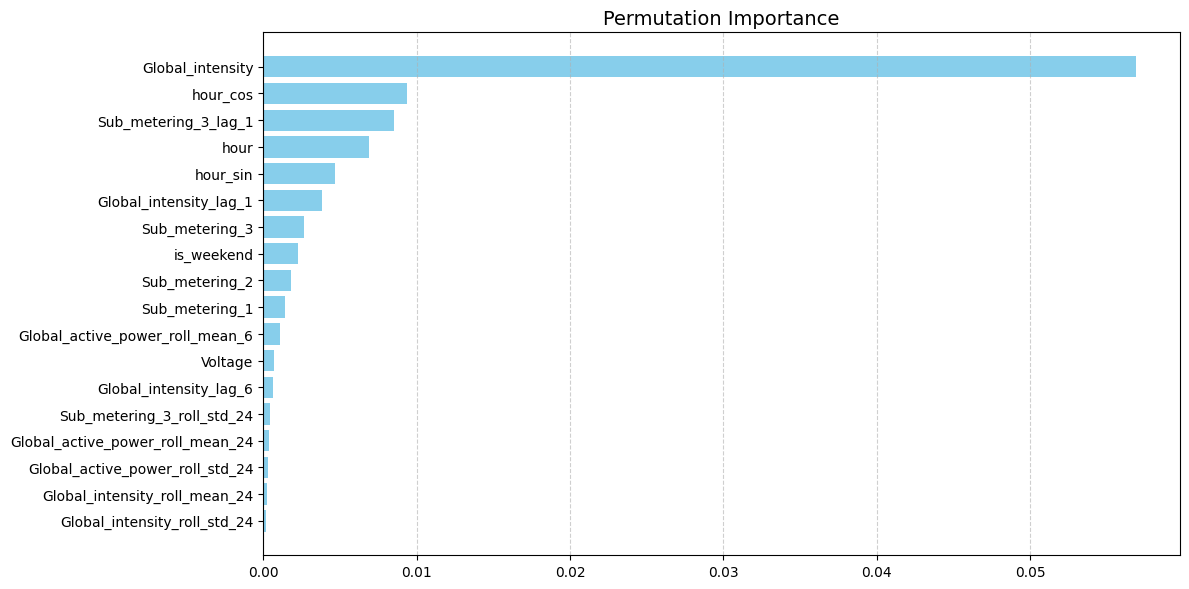

In [226]:
show_importance()

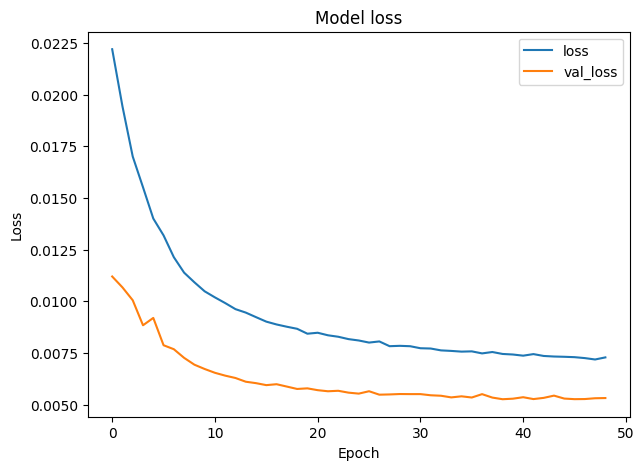

In [223]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show()

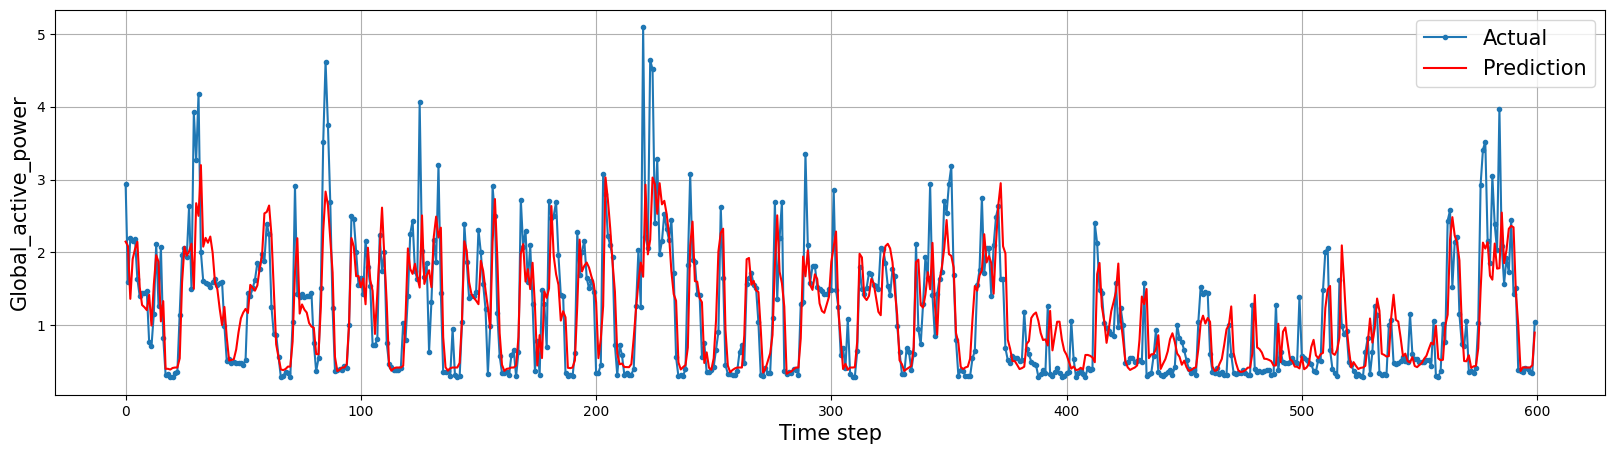

In [224]:
plt.figure(figsize=(20, 5))

# # Ограничим количество точек для визуализации
n = min(600, len(y_test_inv), len(y_pred_inv))
aa = range(n)

plt.plot(aa, y_test_inv[:n], marker='.', label='Actual')
plt.plot(aa, y_pred_inv[:n], 'r', label='Prediction')

plt.ylabel('Global_active_power', fontsize=15)
plt.xlabel('Time step', fontsize=15)
plt.legend(fontsize=15)
plt.grid(True)

plt.show()